In [1]:
# import kagglehub

# Download latest version
# path = kagglehub.dataset_download("davinwijaya/customer-retention")

# print("Path to dataset files:", path)

## domain analysis

Index(['recency', 'history', 'used_discount', 'used_bogo', 'zip_code',
       'is_referral', 'channel', 'offer', 'conversion'],
      dtype='object')
   recency  history  used_discount  used_bogo   zip_code  is_referral channel  \
0       10   142.44              1          0  Surburban            0   Phone   
1        6   329.08              1          1      Rural            1     Web   
2        7   180.65              0          1  Surburban            1     Web   
3        9   675.83              1          0      Rural            1     Web   
4        2    45.34              1          0      Urban            0     Web   

             offer  conversion  
0  Buy One Get One           0  
1         No Offer           0  
2  Buy One Get One           0  
3         Discount           0  
4  Buy One Get One           0  
----
   recency  history  used_discount  used_bogo   zip_code  is_referral channel  \
0       10   142.44              1          0  Surburban            0   Phone  

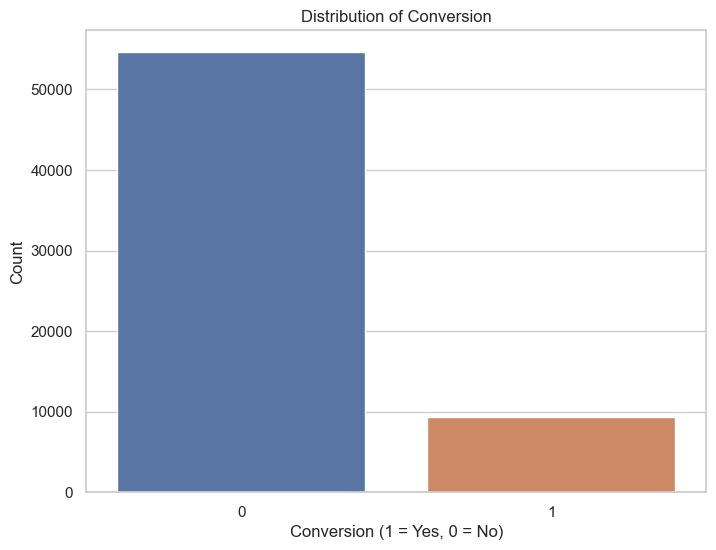

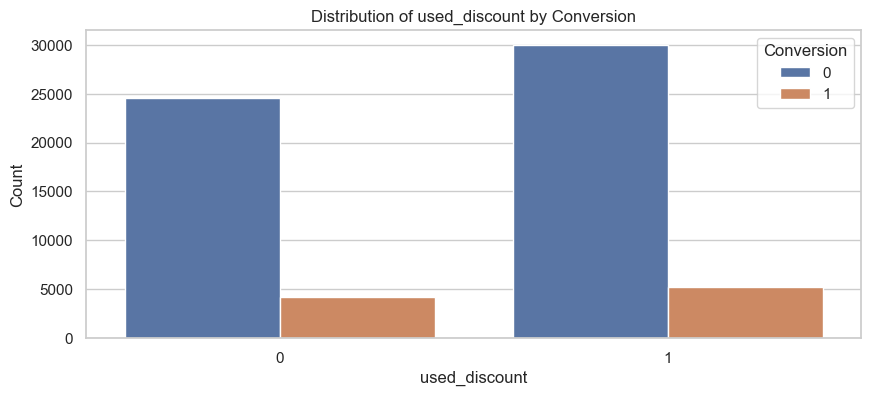

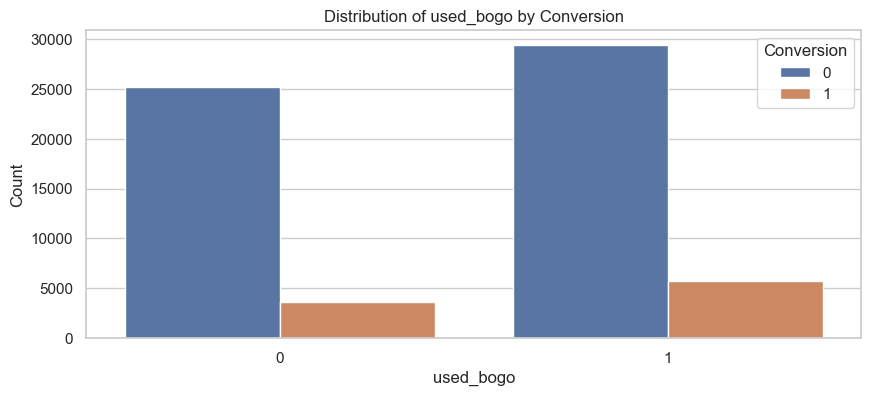

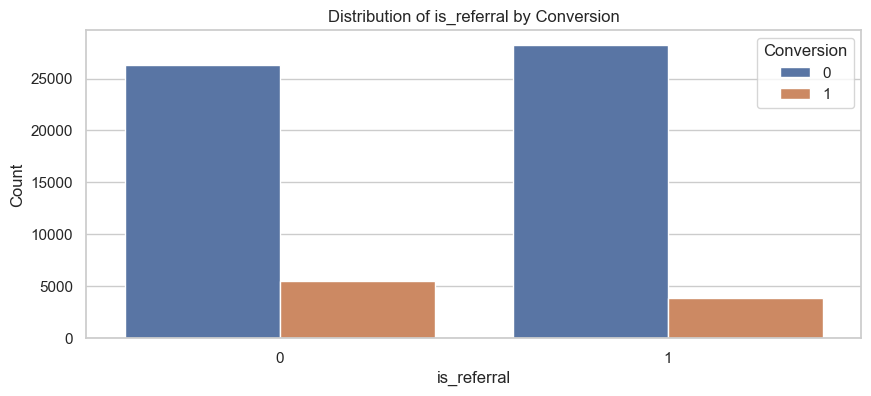

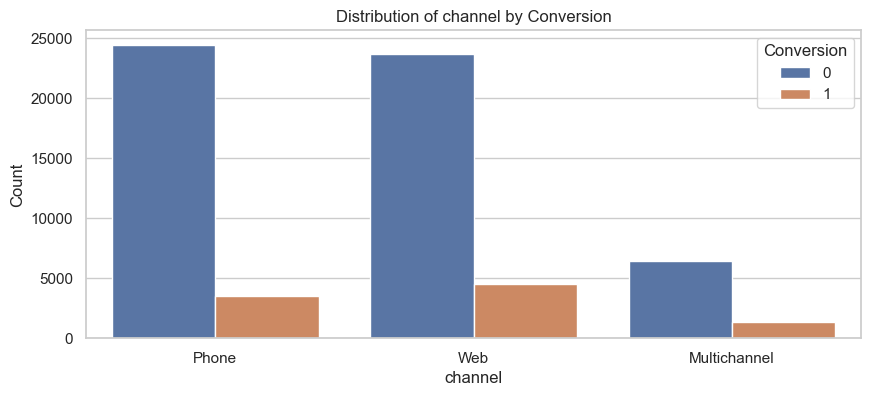

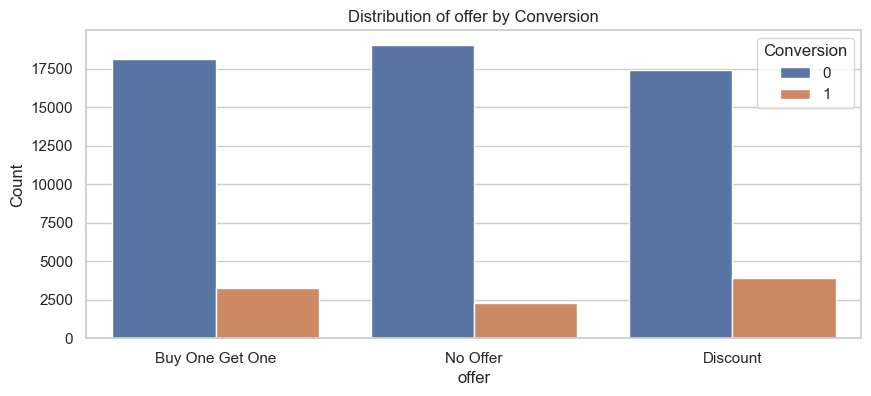

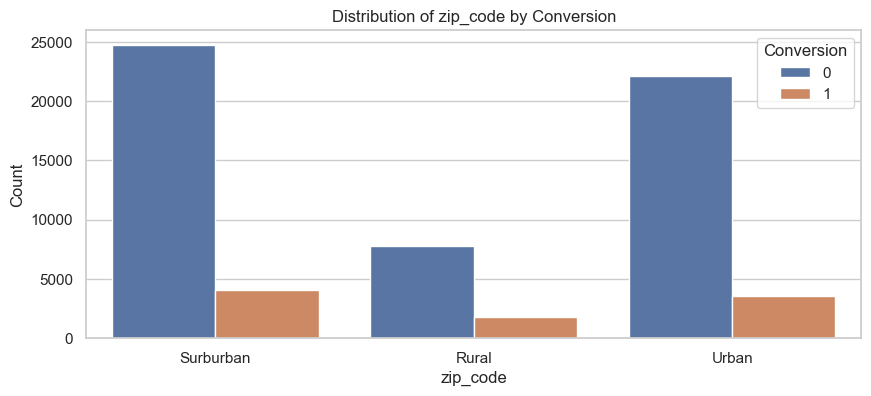

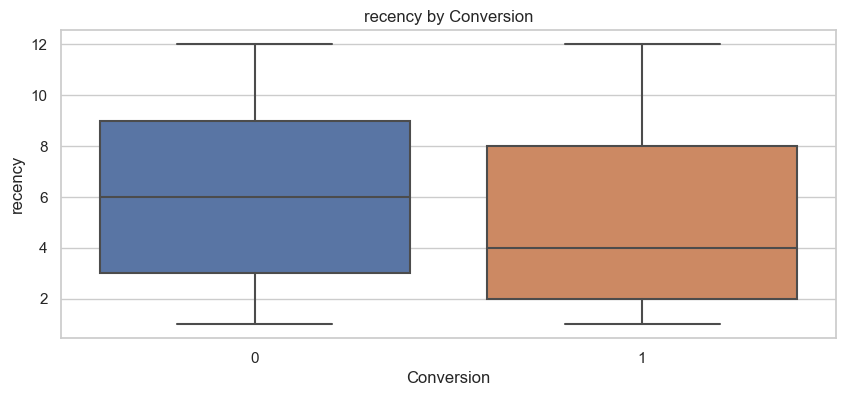

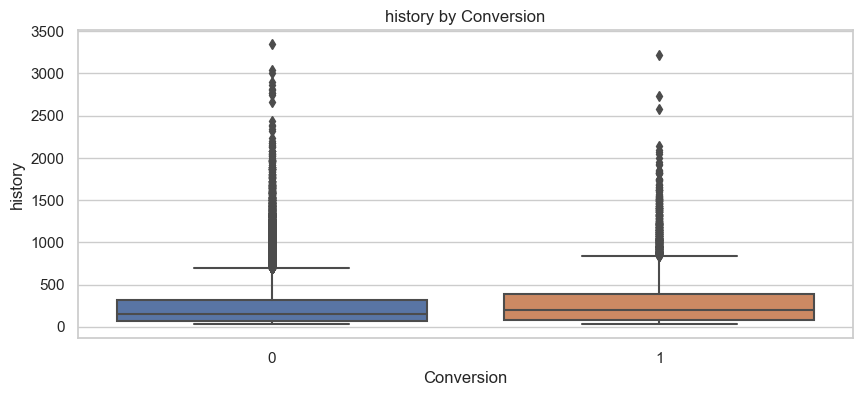

Columns after encoding:
 Index(['recency', 'history', 'conversion', 'used_discount_1', 'used_bogo_1',
       'is_referral_1', 'channel_Phone', 'channel_Web', 'offer_Discount',
       'offer_No Offer', 'zip_code_Surburban', 'zip_code_Urban'],
      dtype='object')


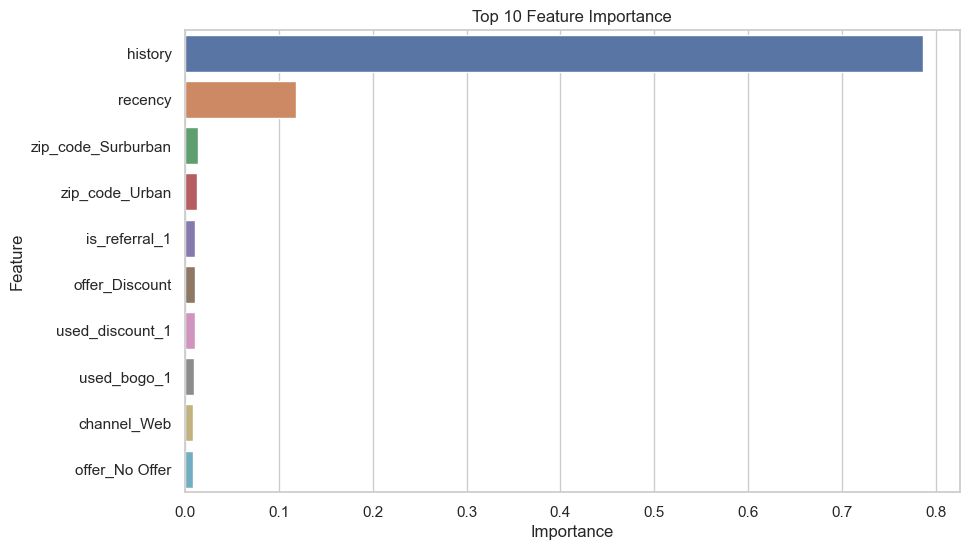

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Set visual style
sns.set(style='whitegrid')

# Load the dataset
url = 'customer-retention.csv'  # Replace with your dataset path
data = pd.read_csv(url)

print(data.columns)

print(data.head())

print('----')

# Display the first few rows
print(data.head())

# Display basic info about the dataset
print(data.info())

# Summary statistics
print(data.describe())

# Check for missing values
missing_data = data.isnull().sum()
print('Missing values per column:\n', missing_data[missing_data > 0])

# Visualize the target variable distribution (Conversion)
plt.figure(figsize=(8, 6))
sns.countplot(x='conversion', data=data)
plt.title('Distribution of Conversion')
plt.xlabel('Conversion (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

# Analyze categorical variables with respect to Conversion
categorical_vars = ['used_discount', 'used_bogo', 'is_referral', 'channel', 'offer', 'zip_code']
for var in categorical_vars:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=var, hue='conversion', data=data)
    plt.title(f'Distribution of {var} by Conversion')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.legend(title='Conversion', loc='upper right')
    plt.show()

# Analyze numerical variables
numerical_vars = ['recency', 'history']
for var in numerical_vars:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='conversion', y=var, data=data)
    plt.title(f'{var} by Conversion')
    plt.xlabel('Conversion')
    plt.ylabel(var)
    plt.show()

# One-Hot Encoding of categorical variables
ohedata = pd.get_dummies(data, columns=categorical_vars, drop_first=True)

# Display updated column names to check
print("Columns after encoding:\n", ohedata.columns)

# Splitting the data into features and target variable
X = ohedata.drop('conversion', axis=1)  # Features
y = ohedata['conversion']                 # Target variable

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Random Forest model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Feature importance
importance = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importance')
plt.show()





## exploratory data analysis

In [3]:
# Exploratory Data Analysis on Customer Retention Dataset
edadata = data.copy()


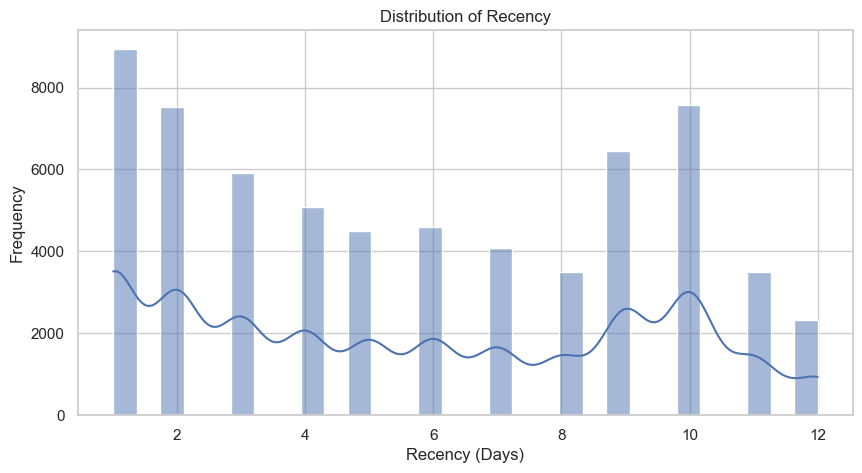

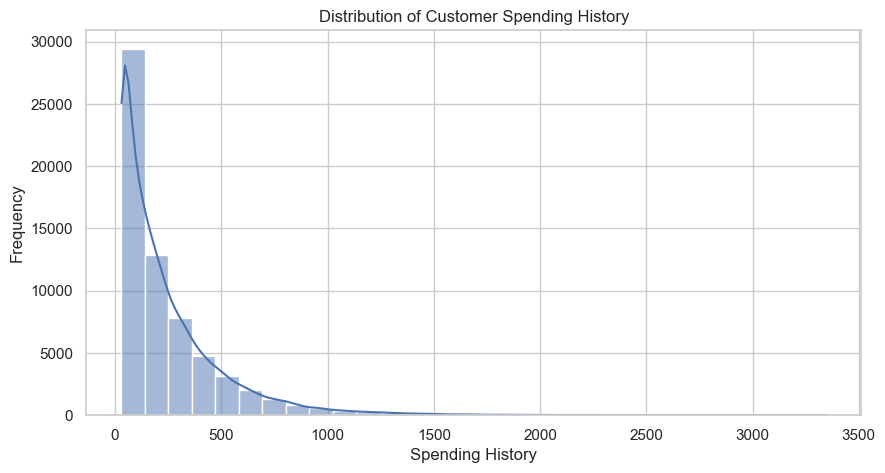

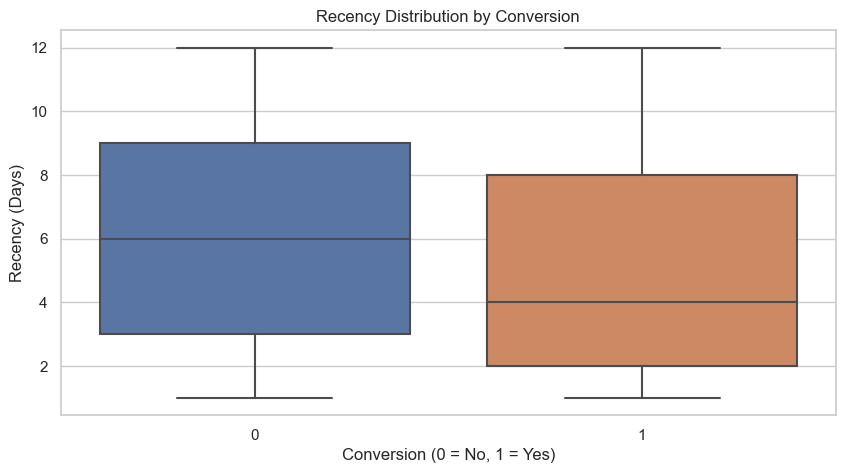

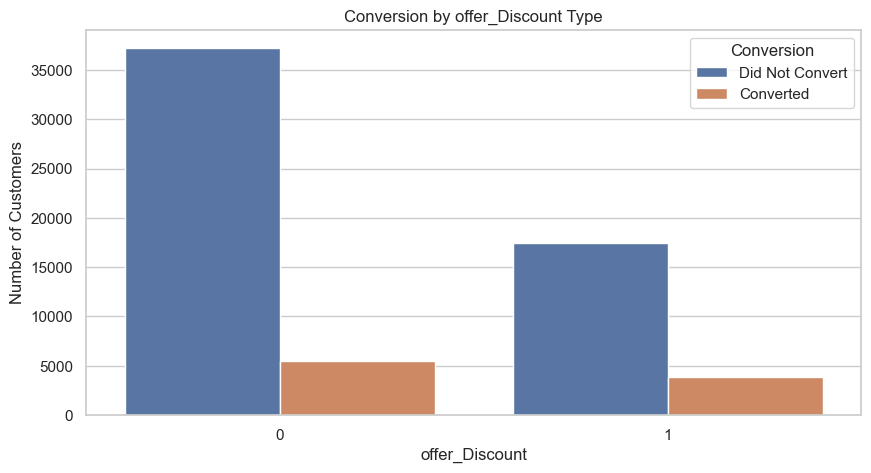

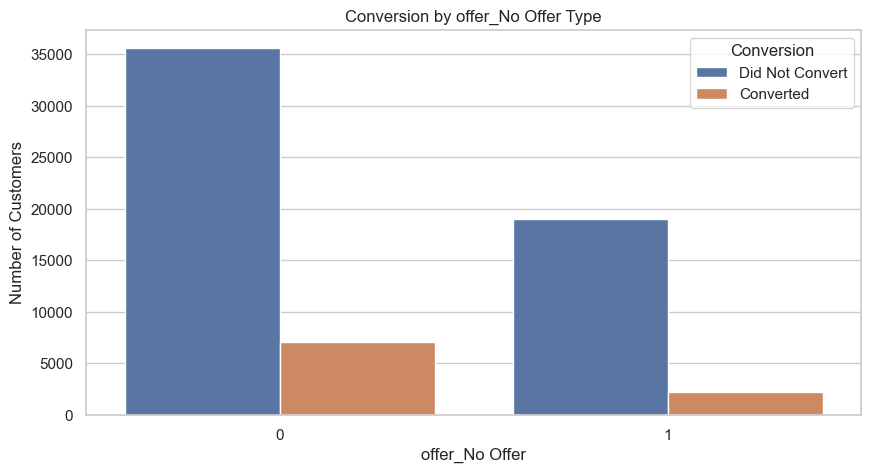

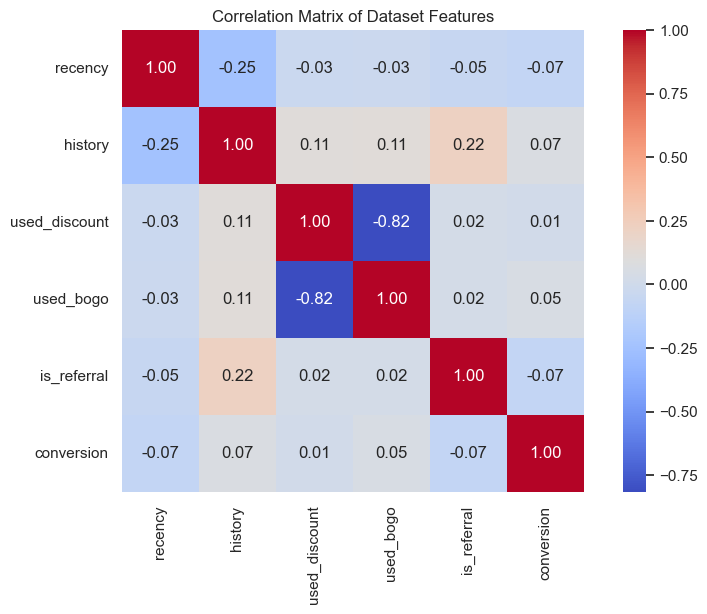

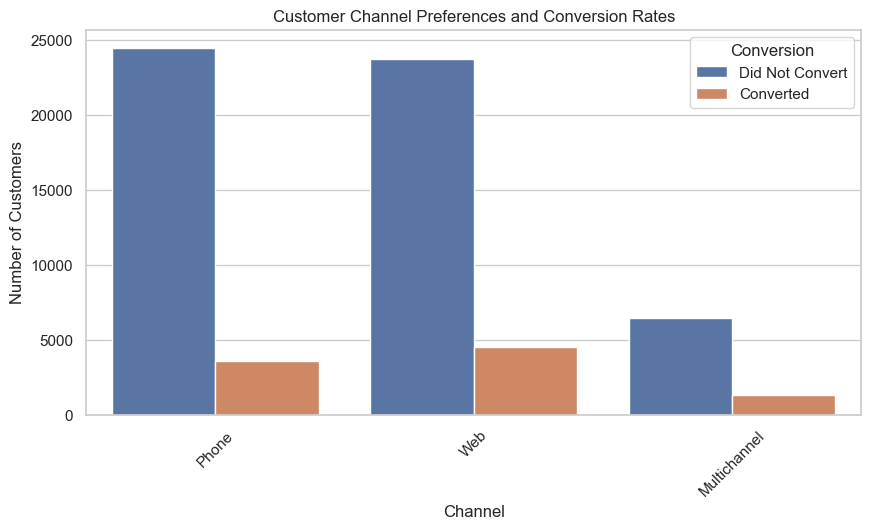

In [4]:

edadata_encoded = pd.get_dummies(edadata, columns=['zip_code', 'offer'], drop_first=True)

# Visualizing the distribution of 'recency'
plt.figure(figsize=(10, 5))
sns.histplot(edadata_encoded['recency'], bins=30, kde=True)
plt.title('Distribution of Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency')
plt.show()

# Visualizing total spending history
plt.figure(figsize=(10, 5))
sns.histplot(edadata_encoded['history'], bins=30, kde=True)
plt.title('Distribution of Customer Spending History')
plt.xlabel('Spending History')
plt.ylabel('Frequency')
plt.show()

# Bivariate analysis: recency vs conversion
plt.figure(figsize=(10, 5))
sns.boxplot(x='conversion', y='recency', data=edadata)
plt.title('Recency Distribution by Conversion')
plt.xlabel('Conversion (0 = No, 1 = Yes)')
plt.ylabel('Recency (Days)')
plt.show()

# Bivariate analysis: conversion by offer types
offer_columns = [col for col in edadata_encoded.columns if 'offer_' in col]
for offer in offer_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=offer, hue='conversion', data=edadata_encoded)
    plt.title(f'Conversion by {offer} Type')
    plt.xlabel(offer)
    plt.ylabel('Number of Customers')
    plt.legend(title='Conversion', labels=['Did Not Convert', 'Converted'])
    plt.show()

# Correlation matrix for numeric columns only
numeric_cols = edadata_encoded.select_dtypes(include=['float64', 'int64']).columns
correlation = edadata_encoded[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Dataset Features')
plt.show()

# Plotting channel distribution without one-hot encoding
plt.figure(figsize=(10, 5))
sns.countplot(data=edadata, x='channel', hue='conversion')
plt.title('Customer Channel Preferences and Conversion Rates')
plt.xlabel('Channel')
plt.ylabel('Number of Customers')
plt.legend(title='Conversion', labels=['Did Not Convert', 'Converted'])
plt.xticks(rotation=45)
plt.show()

## churn prediction using ann

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Load the dataset (replace 'dataset.csv' with your actual dataset file)
# df = pd.read_csv('dataset.csv')

# Sample dataset
data = {
    'recency': [10, 6, 7, 9, 2],
    'history': [142.44, 329.08, 180.65, 675.83, 45.34],
    'used_discount': [1, 1, 0, 1, 1],
    'used_bogo': [0, 1, 1, 0, 0],
    'zip_code': ['Surburban', 'Rural', 'Surburban', 'Rural', 'Urban'],
    'is_referral': [0, 1, 1, 1, 0],
    'channel': ['Phone', 'Web', 'Web', 'Web', 'Web'],
    'offer': ['Buy One Get One', 'No Offer', 'Buy One Get One', 'Discount', 'Buy One Get One'],
    'conversion': [0, 0, 0, 0, 0]
}

df = pd.DataFrame(data)

# Preprocess the dataset
# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=['zip_code', 'channel', 'offer'], drop_first=True)

# Define features and target variable
X = df_encoded.drop(['conversion'], axis=1).values
y = df_encoded['conversion'].values

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Sigmoid activation for binary output

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model with EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(X_train, y_train, epochs=100, batch_size=5, validation_split=0.2, callbacks=[early_stopping])

# Predict probabilities of churn
predictions = model.predict(X_test)
predicted_probabilities = (predictions > 0.5).astype(int)

# Display results
print("Predicted Probabilities of Churn:", predictions.flatten())
print("Predicted Classes:", predicted_probabilities.flatten())

Epoch 1/100
1/1 [==============================] - 2s 2s/step - loss: 0.7776 - accuracy: 0.3333 - val_loss: 0.6239 - val_accuracy: 1.0000
Epoch 2/100
1/1 [==============================] - 0s 36ms/step - loss: 0.7511 - accuracy: 0.3333 - val_loss: 0.6169 - val_accuracy: 1.0000
Epoch 3/100
1/1 [==============================] - 0s 36ms/step - loss: 0.7254 - accuracy: 0.3333 - val_loss: 0.6097 - val_accuracy: 1.0000
Epoch 4/100
1/1 [==============================] - 0s 36ms/step - loss: 0.7028 - accuracy: 0.3333 - val_loss: 0.6025 - val_accuracy: 1.0000
Epoch 5/100
1/1 [==============================] - 0s 56ms/step - loss: 0.6810 - accuracy: 0.3333 - val_loss: 0.5954 - val_accuracy: 1.0000
Epoch 6/100
1/1 [==============================] - 0s 47ms/step - loss: 0.6594 - accuracy: 0.3333 - val_loss: 0.5882 - val_accuracy: 1.0000
Epoch 7/100
1/1 [==============================] - 0s 51ms/step - loss: 0.6371 - accuracy: 0.6667 - val_loss: 0.5811 - val_accuracy: 1.0000
Epoch 8/100
1/1 [=====

1/1 [==============================] - 0s 66ms/step - loss: 0.1210 - accuracy: 1.0000 - val_loss: 0.3529 - val_accuracy: 1.0000
Epoch 60/100
1/1 [==============================] - 0s 64ms/step - loss: 0.1171 - accuracy: 1.0000 - val_loss: 0.3504 - val_accuracy: 1.0000
Epoch 61/100
1/1 [==============================] - 0s 67ms/step - loss: 0.1134 - accuracy: 1.0000 - val_loss: 0.3480 - val_accuracy: 1.0000
Epoch 62/100
1/1 [==============================] - 0s 93ms/step - loss: 0.1098 - accuracy: 1.0000 - val_loss: 0.3456 - val_accuracy: 1.0000
Epoch 63/100
1/1 [==============================] - 0s 60ms/step - loss: 0.1063 - accuracy: 1.0000 - val_loss: 0.3433 - val_accuracy: 1.0000
Epoch 64/100
1/1 [==============================] - 0s 37ms/step - loss: 0.1029 - accuracy: 1.0000 - val_loss: 0.3410 - val_accuracy: 1.0000
Epoch 65/100
1/1 [==============================] - 0s 34ms/step - loss: 0.0997 - accuracy: 1.0000 - val_loss: 0.3387 - val_accuracy: 1.0000
Epoch 66/100
1/1 [========